# TODO: 
* run stage 1 single algorithm for: RLD2 100 linear (and new nonlinear), new RLD2_FILTERED(N=10) lin and nonline, and for Linear solver.
* makes notes in readme about what each file does
* include RLD2 and linear results here.
* Write check in run_stage_1single_algorithm that resulting team is in filter!

In [1]:
import pandas as pd
import pickle
import numpy as np
import superscript_abm

from radar_methods import *
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def load_results(path):
    with open(path, 'rb') as infile:
        results = pickle.load(infile)
        
    return results

In [3]:
# greedy = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_greedy_run_1/results.pickle')
# grasp = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_grasp_run_0/results.pickle')
# random = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_random_run_1/results.pickle')

greedy = load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_greedy_final_run_0/results.pickle')
grasp = load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_grasp_final_run_0/results.pickle')
# random = load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_random_final_run_0/results.pickle')

In [4]:
greedy_100 = {}
grasp_100 = {}
# random_100 = {}

for cpt in greedy.keys():
    if cpt.split('_')[0] == 'probability' and len(cpt.split('_')) > 1:
        print(cpt)
        greedy_100[cpt.split('_')[1]] = np.mean(greedy[cpt])
        grasp_100[cpt.split('_')[1]] = np.mean(grasp[cpt])
        # random_100[cpt.split('_')[1]] = np.mean(random[cpt])

probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk


In [5]:
greedy_100

{'ovr': 0.24998109993060658,
 'skill': 0.7933296099306424,
 'creativity': 0.9940554762853153,
 'individual': 0.8342698412698413,
 'team': 0.8918095238095237,
 'risk': 0.4859999999999999}

In [6]:
# which_rld2 = 'rld2_100_10'
which_rld2 = 'rld2_100_10'
reduced_size = 20

In [7]:
def get_data_list(greedy, grasp, rld2):

    _greedy = {}
    _grasp = {}
    _rld2 = {}

    _greedy_total_prob = []
    _grasp_total_prob = []
    _rld2_total_prob = []
    
    for cpt in greedy.keys():
        if cpt.split('_')[0] == 'probability' and len(cpt.split('_')) > 1:
            print(cpt)
            _greedy[cpt.split('_')[1]] = np.mean(greedy[cpt])
            _grasp[cpt.split('_')[1]] = np.mean(grasp[cpt])
            _rld2[cpt.split('_')[1]] = np.mean(rld2[cpt])
        
        elif cpt.split('_')[0] == 'probability' and len(cpt.split('_')) == 1:
            # _greedy_total_prob = [val if val is not None else 0.0 for val in greedy[cpt]]
            # _grasp_total_prob = [val if val is not None else 0.0 for val in grasp[cpt]]
            # _rld2_total_prob = [val if val is not None else 0.0 for val in rld2[cpt]]
            _greedy_mean_prob = np.mean([val if val is not None else 0.0 for val in greedy[cpt]])
            _grasp_mean_prob = np.mean([val if val is not None else 0.0 for val in grasp[cpt]])
            _rld2_mean_prob = np.mean([val if val is not None else 0.0 for val in rld2[cpt]])
            
    return [
            list(_greedy.values()),
            list(_grasp.values()),
            list(_rld2.values()),
        ], [
            _greedy_mean_prob,
            _grasp_mean_prob,
            _rld2_mean_prob
        ]

def combine_data_lists(components):

    lin_100 = get_data_list(
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_linear/dataset_1_greedy_run_0/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_linear/dataset_1_grasp_run_0/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_linear/dataset_1_random_run_1/results.pickle')
             # load_results('../stage_1_results/single_algorithm/stage_1_dataset_1_100_workers_linear/dataset_1_greedy_final_run_0/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_dataset_1_100_workers_linear/dataset_1_grasp_final_run_0/results.pickle'),
             # load_results(f"../stage_1_results/single_algorithm/stage_1_dataset_1_100_workers_linear/dataset_1_{which_rld2}_final_run_0/results.pickle")

            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_greedy_final_run_0/results.pickle'),
            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_grasp_final_run_2025/results.pickle'),
            load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_{which_rld2}_final_run_1/results.pickle")
            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_{which_rld2}_final_run_0/results.pickle")
            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_linear/test_dataset_rld2_final_run_0/results.pickle")
         )
    lin_10 = get_data_list(
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_linear/dataset_1_greedy_run_1/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_linear/dataset_1_grasp_run_0/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_linear/dataset_1_random_run_1/results.pickle')
            # load_results(f'../stage_1_results/single_algorithm/stage_1_dataset_1_{reduced_size}_workers_linear/dataset_1_greedy_final_run_0/results.pickle'),
            # load_results(f'../stage_1_results/single_algorithm/stage_1_dataset_1_{reduced_size}_workers_linear/dataset_1_grasp_final_run_0/results.pickle'),
            # # load_results(f"../stage_1_results/single_algorithm/stage_1_dataset_1_{reduced_size}_workers_linear/dataset_1_{which_rld2}_final_run_0/results.pickle")
            # load_results(f'../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_random_run_1/results.pickle')
            
        load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_linear/test_dataset_greedy_final_run_0/results.pickle'),
            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_linear/test_dataset_grasp_final_run_2025/results.pickle'),
            load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_linear/test_dataset_{which_rld2}_final_run_0/results.pickle")
         )

    nonlin_100 = get_data_list(
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_greedy_run_1/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_grasp_run_0/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_random_run_1/results.pickle')
            # load_results('../stage_1_results/single_algorithm/stage_1_dataset_1_100_workers_nonlinear/dataset_1_greedy_final_run_0/results.pickle'),
            # load_results('../stage_1_results/single_algorithm/stage_1_dataset_1_100_workers_nonlinear/dataset_1_grasp_final_run_0/results.pickle'),
            # load_results(f"../stage_1_results/single_algorithm/stage_1_dataset_1_100_workers_nonlinear/dataset_1_{which_rld2}_final_run_0/results.pickle")

            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_greedy_final_run_0/results.pickle'),
            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_grasp_final_run_2025/results.pickle'),
            load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_{which_rld2}_final_run_1/results.pickle")
            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_greedy_rl_final_run_4/results.pickle")

            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_{which_rld2}_final_run_0/results.pickle")
            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_rld2_final_run_0/results.pickle")
         )
    nonlin_10 =  get_data_list(
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_greedy_run_0/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_grasp_run_1/results.pickle'),
             # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_random_run_1/results.pickle')
            
            # load_results(f'../stage_1_results/single_algorithm/stage_1_dataset_1_{reduced_size}_workers_nonlinear/dataset_1_greedy_final_run_0/results.pickle'),
            # load_results(f'../stage_1_results/single_algorithm/stage_1_dataset_1_{reduced_size}_workers_nonlinear/dataset_1_grasp_final_run_0/results.pickle'),
            # # load_results(f"../stage_1_results/single_algorithm/stage_1_dataset_1_{reduced_size}_workers_nonlinear/dataset_1_{which_rld2}_final_run_0/results.pickle")
            # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_random_run_1/results.pickle')
            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_nonlinear/test_dataset_greedy_final_run_0/results.pickle'),
            load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_nonlinear/test_dataset_grasp_final_run_2025/results.pickle'),
            load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_nonlinear/test_dataset_{which_rld2}_final_run_1/results.pickle")

            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_nonlinear/test_dataset_ensemble_final_run_0/results.pickle")

            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_15_workers_nonlinear/test_dataset_{which_rld2}_final_run_0/results.pickle")
            # load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_{reduced_size}_workers_nonlinear/test_dataset_{which_rld2}_final_run_1/results.pickle")
                
        # load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_random_run_1/results.pickle')

         )
    
    data = [
        components,
        ('100 Workers, Linear', lin_100[0]),
        (f'{reduced_size} Workers, Linear', lin_10[0]),
        ('100 Workers, Nonlinear', nonlin_100[0]),
        (f'{reduced_size} Workers, Nonlinear', nonlin_10[0])
    ]
    probs = {
        'lin_100': lin_100[1],
        'lin_10': lin_10[1],
        'nonlin_100': nonlin_100[1],
        'nonlin_10': nonlin_10[1],
    }
    return data, probs

In [11]:
# components = [cpt.split('_')[1] for cpt in greedy.keys() if cpt.split('_')[0] == 'probability' and len(cpt.split('_')) > 1]

In [21]:
data, probs = combine_data_lists(components)

probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk
probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk
probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk
probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk


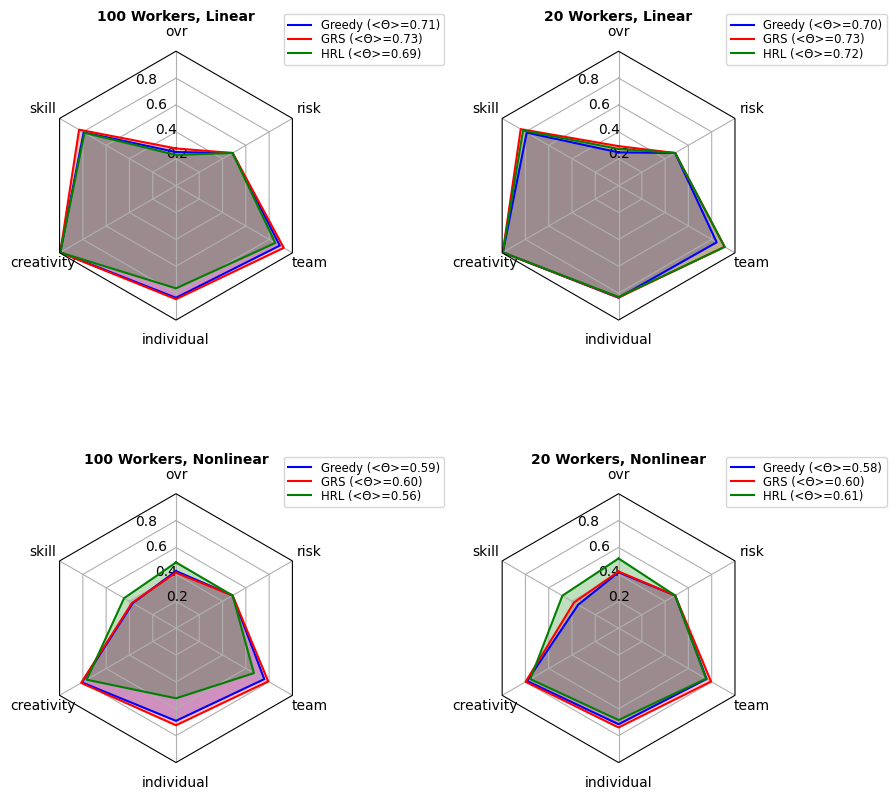

In [22]:
N = 6
theta = radar_factory(N, frame='polygon')

spoke_labels = data.pop(0)

fig, axs = plt.subplots(figsize=(9, 9), nrows=2, ncols=2,
                        subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

plt.rcParams['text.usetex'] = False

colors = ['b', 'r', 'g']
# Plot the four cases from the example data on separate Axes
for ai, ax in enumerate(axs.flat):
    title = data[ai][0]
    case_data = data[ai][1]
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
    ax.set_rlim(0,1)
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                 horizontalalignment='center', verticalalignment='center')
    for d, color in zip(case_data, colors):
        ax.plot(theta, d, color=color)
        ax.fill(theta, d, facecolor=color, alpha=0.25, label='_nolegend_')
    ax.set_varlabels(spoke_labels)

# add legend relative to top-left plot
    if ai == 2:
        labels = (
        f'Greedy (<Θ>={list(probs.values())[ai][0]:.2f})', 
        f'GRS (<Θ>={list(probs.values())[ai][1]:.2f})', 
        # f'GreedyRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        f'HRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        )
    elif ai == 3:
        labels = (
        f'Greedy (<Θ>={list(probs.values())[ai][0]:.2f})', 
        f'GRS (<Θ>={list(probs.values())[ai][1]:.2f})', 
        f'HRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        # f'Ensemble (<Θ>={list(probs.values())[ai][2]:.2f})'
        )
    else:
        labels = (
            f'Greedy (<Θ>={list(probs.values())[ai][0]:.2f})', 
            f'GRS (<Θ>={list(probs.values())[ai][1]:.2f})', 
            f'HRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        )
    legend = ax.legend(labels, loc=(0.9, .95),
                              labelspacing=0.1, fontsize='small')
    
# fig.text(0.5, 0.965, 'Best model solutions averaged over test dataset',
#          horizontalalignment='center', color='black', weight='bold',
#          size='large')

plt.tight_layout()
plt.savefig('radar_plot_main_algorithms.png', dpi=300)

Text(0.5, 0.965, 'Best model solutions averaged over test dataset')

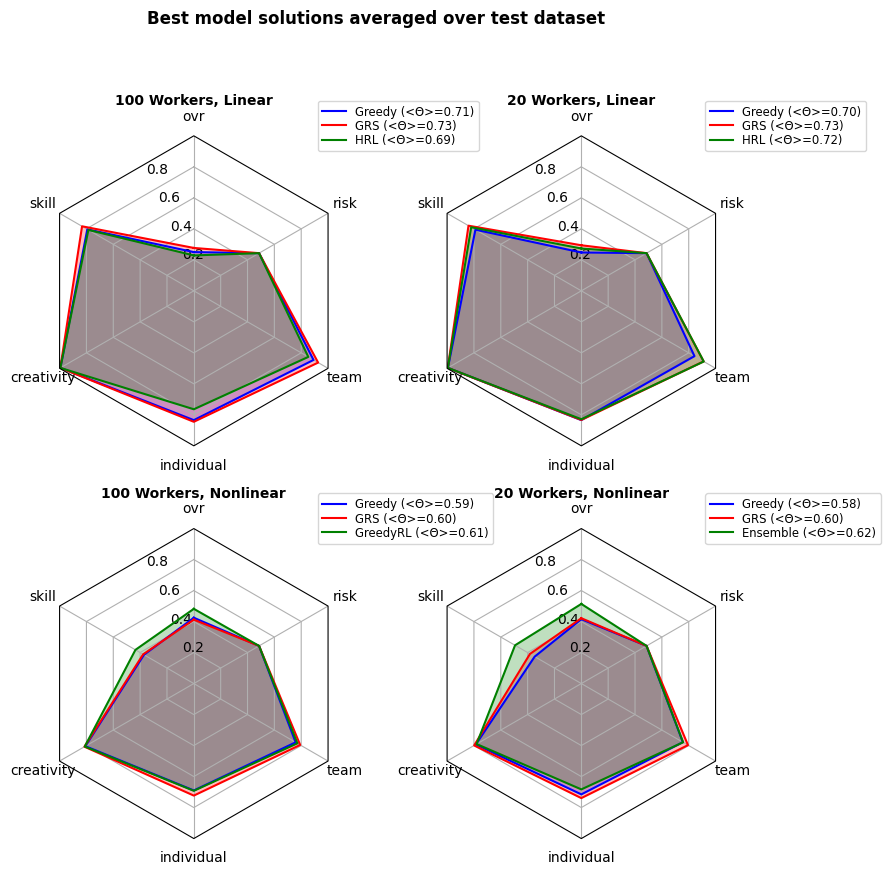

In [24]:
N = 6
theta = radar_factory(N, frame='polygon')

spoke_labels = data.pop(0)

fig, axs = plt.subplots(figsize=(9, 9), nrows=2, ncols=2,
                        subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

plt.rcParams['text.usetex'] = False

colors = ['b', 'r', 'g']
# Plot the four cases from the example data on separate Axes
for ai, ax in enumerate(axs.flat):
    title = data[ai][0]
    case_data = data[ai][1]
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
    ax.set_rlim(0,1)
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                 horizontalalignment='center', verticalalignment='center')
    for d, color in zip(case_data, colors):
        ax.plot(theta, d, color=color)
        ax.fill(theta, d, facecolor=color, alpha=0.25, label='_nolegend_')
    ax.set_varlabels(spoke_labels)

# add legend relative to top-left plot
    if ai == 2:
        labels = (
        f'Greedy (<Θ>={list(probs.values())[ai][0]:.2f})', 
        f'GRS (<Θ>={list(probs.values())[ai][1]:.2f})', 
        f'GreedyRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        # f'HRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        )
    elif ai == 3:
        labels = (
        f'Greedy (<Θ>={list(probs.values())[ai][0]:.2f})', 
        f'GRS (<Θ>={list(probs.values())[ai][1]:.2f})', 
        # f'HRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        f'Ensemble (<Θ>={list(probs.values())[ai][2]:.2f})'
        )
    else:
        labels = (
            f'Greedy (<Θ>={list(probs.values())[ai][0]:.2f})', 
            f'GRS (<Θ>={list(probs.values())[ai][1]:.2f})', 
            f'HRL (<Θ>={list(probs.values())[ai][2]:.2f})'
        )
    legend = ax.legend(labels, loc=(0.9, .95),
                              labelspacing=0.1, fontsize='small')
    
fig.text(0.5, 0.965, 'Best model solutions averaged over test dataset',
         horizontalalignment='center', color='black', weight='bold',
         size='large')

In [266]:
.67/.70

0.9571428571428573

In [ ]:
# def plot_two_radars(_data):
#     N = 6
#     theta = radar_factory(N, frame='polygon')
    
#     spoke_labels = _data.pop(0)
    
#     fig, axs = plt.subplots(figsize=(9, 9), nrows=1, ncols=2,
#                             subplot_kw=dict(projection='radar'))
#     fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)
    
#     colors = ['b', 'r', 'g']
#     # Plot the four cases from the example data on separate Axes
#     for ax, (title, case_data) in zip(axs.flat, _data):
#         ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
#         ax.set_rlim(0,1)
#         ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
#                      horizontalalignment='center', verticalalignment='center')
#         for d, color in zip(case_data, colors):
#             ax.plot(theta, d, color=color)
#             ax.fill(theta, d, facecolor=color, alpha=0.25, label='_nolegend_')
#         ax.set_varlabels(spoke_labels)
    
#     # add legend relative to top-left plot
#     labels = ('Greedy', 'GRASP', 'RLD2')
#     legend = axs[0, 0].legend(labels, loc=(0.9, .95),
#                               labelspacing=0.1, fontsize='small')
    
#     fig.text(0.5, 0.965, 'Linear and Nonlinear scenarios for 100 workers',
#              horizontalalignment='center', color='black', weight='bold',
#          size='large')

In [58]:
which_rld2 = 'rld2_100_10'
greedy = load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_greedy_final_run_0/results.pickle'),
grasp = load_results(f'../stage_1_results/single_algorithm/stage_1_test_dataset_100_workers_nonlinear/test_dataset_grasp_final_run_2025/results.pickle'),
rld2 = load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_20_workers_nonlinear/test_dataset_{which_rld2}_final_run_0/results.pickle")
# rld2 = load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_20_workers_nonlinear/test_dataset_{which_rld2}_final_run_1/results.pickle")
# rld2 = load_results(f"../stage_1_results/single_algorithm/stage_1_test_dataset_15_workers_nonlinear/test_dataset_{which_rld2}_final_run_0/results.pickle")

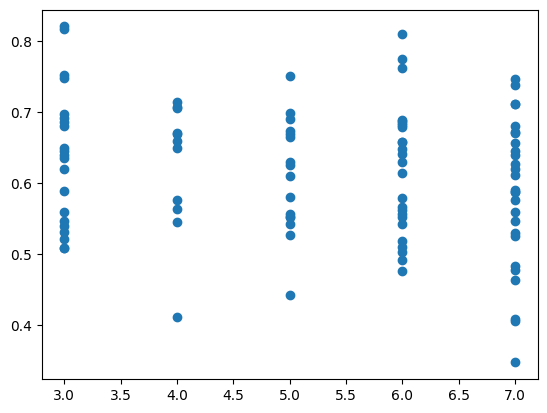

In [59]:
plt.scatter(rld2['team_size'], rld2['probability'])

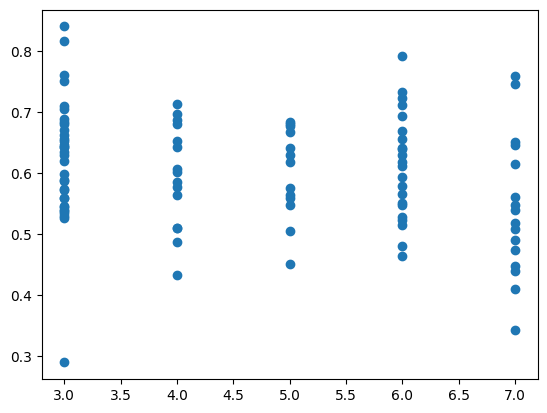

In [60]:
plt.scatter(grasp[0]['team_size'], grasp[0]['probability'])

In [61]:
print(np.mean(greedy[0]['team_size']))
print(np.mean(grasp[0]['team_size']))
print(np.mean(rld2['team_size']))

5.02
4.71
5.26


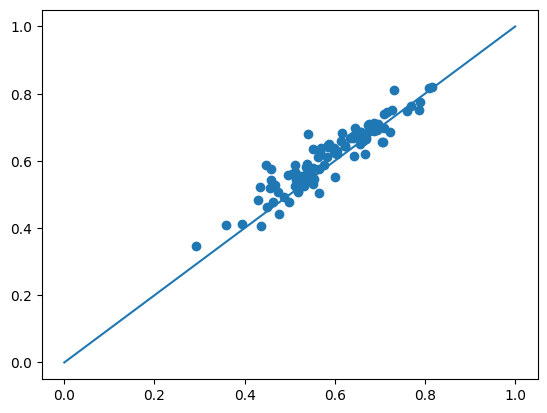

In [62]:
plt.scatter(greedy[0]['probability'], rld2['probability'])
plt.plot([0.0, 1.0], [0.0, 1.0])

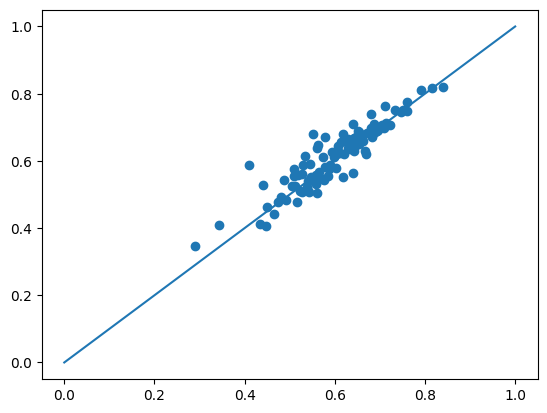

In [43]:
plt.scatter(grasp[0]['probability'], rld2['probability'])
plt.plot([0.0, 1.0], [0.0, 1.0])

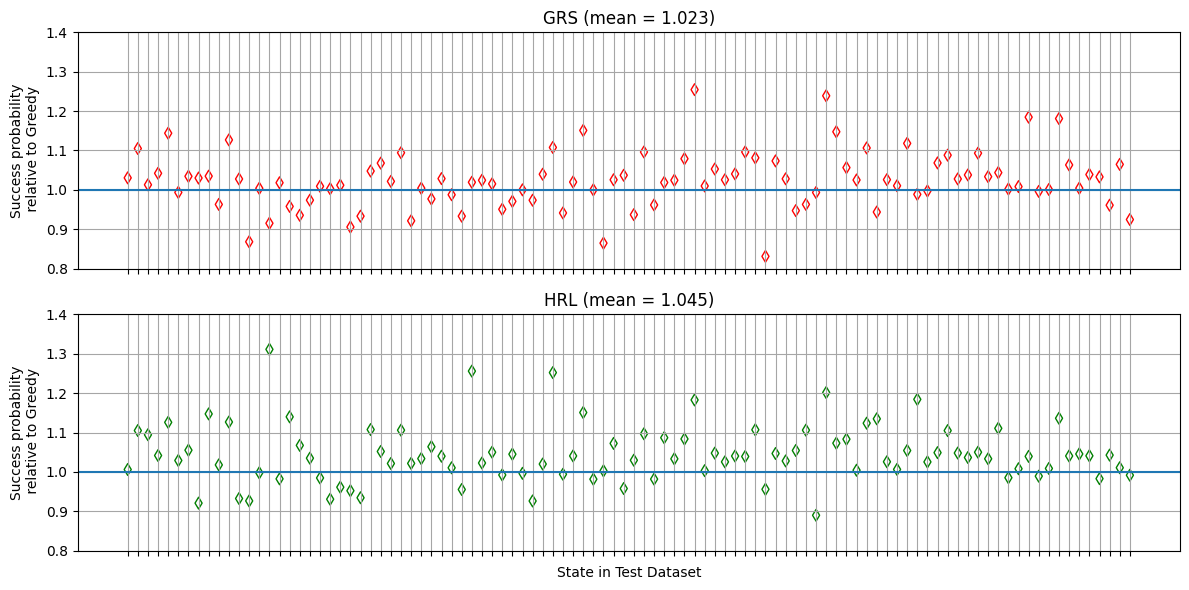

In [105]:
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.scatter(
    list(range(100)),
    [
        r/g for g,r in zip(greedy[0]['probability'], grasp[0]['probability'])
    ],
    marker='d',
    facecolors='none',
    edgecolors='r'
)

grs_av = np.mean([
        r/g for g,r in zip(greedy[0]['probability'], grasp[0]['probability'])
    ])
plt.axhline(1.0)
plt.xticks(ticks=range(100), labels="")
plt.grid(visible=True, which='both', color='0.65', linestyle='-')
plt.ylim([0.8, 1.4])
plt.ylabel("Success probability\n relative to Greedy")

plt.title(f"GRS (mean = {grs_av:.3f})")

plt.subplot(2,1,2)
plt.scatter(
    list(range(100)),
    [
        r/g for g,r in zip(greedy[0]['probability'], rld2['probability'])
    ],
    marker='d',
    facecolors='none',
    edgecolors='g')

hrl_av = np.mean([
        r/g for g,r in zip(greedy[0]['probability'], rld2['probability'])
    ])
plt.axhline(1.0)
plt.xticks(ticks=range(100), labels="")
plt.xlabel("State in Test Dataset")
plt.ylabel("Success probability\n relative to Greedy")
plt.grid(visible=True, which='both', color='0.65', linestyle='-')
plt.ylim([0.8, 1.4])
plt.title(f"HRL (mean = {hrl_av:.3f})")

plt.tight_layout()

In [400]:
np.mean(greedy[0]['probability'])

0.5896542626572705

In [401]:
np.mean(rld2['probability'])

0.6134726263648765

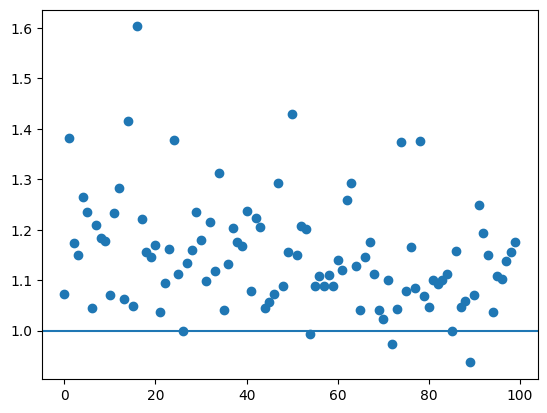

In [403]:
plt.scatter(
    list(range(100)),
    [
        r/g for g,r in zip(grasp[0]['probability'], rld2['probability'])
    ])
plt.axhline(1.0)

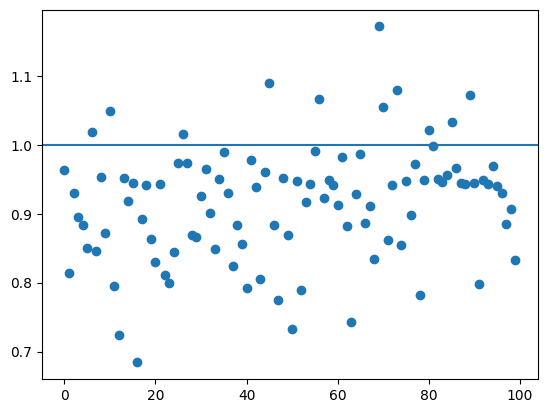

In [405]:
plt.scatter(
    list(range(100)),
    [
        r/g for g,r in zip(greedy[0]['probability'], grasp[0]['probability'])
    ])
plt.axhline(1.0)